Este notebook fue creado por Francisca Cattan (2024) para el workshop de final de curso IIC2233 Proramación Avanzada.

fpcattan@uc.cl

# Machine Learning
<img src='https://miro.medium.com/v2/resize:fit:640/format:webp/0*zRc3gOev20t1przG.jpg'>

El Machine Learning es una rama de la inteligencia artificial que permite a las máquinas aprender a partir de datos, sin necesidad de ser programadas explícitamente para cada tarea. En lugar de definir reglas manuales para resolver un problema, los modelos de ML aprenden patrones y relaciones directamente desde los datos.

Los modelos de ML aprenden directamente de datos estructurados como tablas numéricas. Más datos generalmente permiten construir modelos más precisos. Un buen balance entre la dificultad de la tarea, la disponibilidad y cantidad de datos, y la complejidad del modelo es fundamental.

Se usa en una variedad de problemas, como:
- Clasificación (spam/no spam, música).
- Regresión (predicción de precios, costos, popularidad).
- Clustering (agrupación de perfiles de grupos, estilos).

### Pasos de ML (e IA en general)
1. **Datos**: El proceso comienza con datos tabulares o simples que deben estar bien estructurados.
2. **Preprocesamiento**: Incluye tareas como limpieza de datos, escalado y manejo de valores faltantes para preparar los datos para el modelo.
3. **Ingeniería de Características**: Se diseñan manualmente variables relevantes (features) basadas en el conocimiento del dominio y el problema.
4. **Modelo**: Se selecciona y entrena un modelo como SVM, Regresión Logística, o Árboles de Decisión.
Predicción:
El modelo predice el resultado en base a las características procesadas.

## 1. Preparacion de datos: Dataset Iris
Trabajaremos con el set de datos **Iris** de **[Seaborn](https://seaborn.pydata.org/index.html)**. Seaborn es una librería de visualización, mucho mas potente en variedad que `matplotlib`. Además, cuenta con datos dentro de la librería. Esto es muy usual en las librerías actuales de ML y DL, los cuales tienen ya empaquetados no sólo modelos si no que también datasets. Veamos los datos disponibles en Seaborn.

In [2]:
import seaborn as sns
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

El dataset **Iris** tiene 50 muestras de cada una de las tres especies de flores de Iris (Setosa, Virginica y Versicolor). Se midieron cuatro características (en centímetros) de cada muestra: Largo y Ancho de los Sépalos y Pétalos.

Tratemos de tener una vista resumida de este conjunto de datos:

In [3]:
# importamos las primeras librerias
"""
%matplotlib inline magic command específico de Jupyter Notebook. Asegura que los
gráficos generados con matplotlib se muestren directamente en la celda de salida
del notebook, en lugar de abrirse en una ventana separada.
"""
%matplotlib inline
import seaborn as sns; sns.set()

In [4]:
# el dataset viene dentro de la libreria Seaborn
iris = sns.load_dataset('iris')
iris.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Google Colab tiene una herramienta de integración con los Dataframes de Pandas, que permite replicar los datos en un documento tabulado de Google (Google Sheets).

In [5]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=iris)

https://docs.google.com/spreadsheets/d/1hEprUDJq2MOdDHE88-h9leZWAvWUUmcCrbqlIWDTZrE#gid=0


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


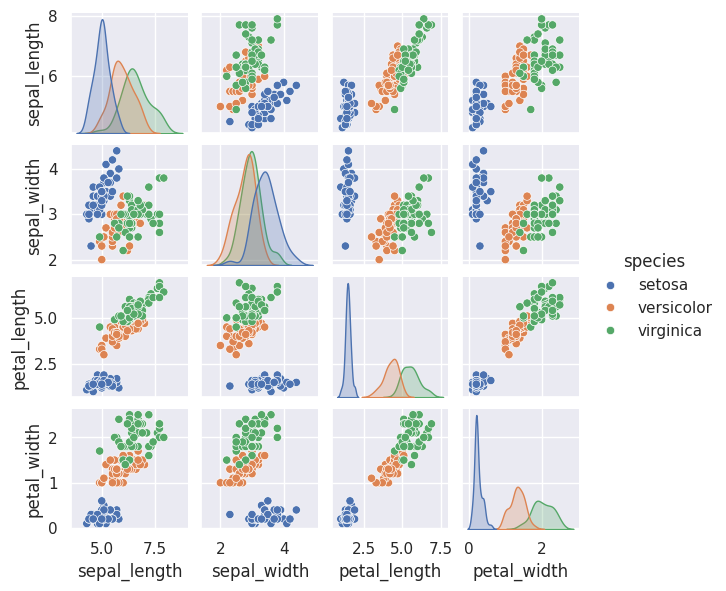

In [6]:
sns.pairplot(iris, hue='species', size=1.5)

In [7]:
# Vamos a seleccionar el X, que son los datos de entrenamiento
X = iris.drop('species',axis=1) # sacamos las especies, que son las etiquetas
print(X.shape)
X.head()

(150, 4)


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
# creamos las etiquetas, ya que queremos clasificar nuevas flores.
y = iris['species']
print(y.shape)
y.describe()

(150,)


,species
count,150
unique,3
top,setosa
freq,50


## 2. Sets de entrenamiento y test

[Scikit-learn](https://scikit-learn.org/1.5/index.html) (o sklearn) es una biblioteca de aprendizaje automático en Python que proporciona herramientas simples, eficientes y fáciles de usar para realizar tareas de análisis predictivo y procesamiento de datos.

- Modelado supervisado: Clasificación y regresión (e.g., SVM, Árboles de decisión, Redes neuronales).
- Modelado no supervisado: Clustering, reducción de dimensionalidad (e.g., K-Means, PCA).
- Preprocesamiento de datos: Normalización, escalado y manejo de datos faltantes.
- Evaluación de modelos: Validación cruzada, métricas de evaluación.

Ahora vamos a usar la librería `sklearn` para importar metricas y dividir los datos. `sklearn` nos entrega facilmente una forma de dividir. Revisar la documentacion del modulo [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html?highlight=train_test_split#sklearn.model_selection.train_test_split).

In [9]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [12]:
# Convertimos las etiquetas (y) de texto a valores numéricos usando LabelEncoder
# Esto es necesario porque XGBoost solo acepta etiquetas numéricas.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Etiquetas transformadas:")
# mapeo entre las etiquetas originales y los números asignados.
print(label_encoder.classes_)  # ['setosa' 'versicolor' 'virginica']

Etiquetas transformadas:
['setosa' 'versicolor' 'virginica']


In [13]:
# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

## 3. Entrenamiento

Existen muchas técnicas de entrenamiento de Machine Learning. A continuación detallaré las más clásicas, y las más usadas en la actualidad.

### Técnicas clásicas
- **Regresión Lineal y Logística**: Modelos simples para problemas de regresión (continuos) y clasificación binaria o multiclase.
  - Uso clásico: Excelentes para datos pequeños y bien estructurados donde la interpretabilidad es importante.
  - Por qué aún se usan: Son rápidos, interpretables y funcionan como líneas base sólidas.
  - Por qué a veces no se usan: No manejan bien relaciones no lineales complejas o datos de alta dimensionalidad.

- **Árboles de Decisión**: Dividen los datos en regiones homogéneas usando reglas basadas en características.
  - Uso clásico: Simples de entender e interpretar; funcionan bien en datos estructurados.
  - Por qué aún se usan: Interpretación directa y rápida.
  - Por qué a veces no se usan: Pueden sobreajustarse fácilmente; los modelos ensamblados (Random Forest, Gradient Boosting) los han reemplazado en muchos casos.

- **K-Nearest Neighbors** (KNN): Clasifica puntos basándose en las clases más comunes entre sus vecinos más cercanos.
  - Uso clásico: Simple y no requiere entrenamiento explícito.
  - Por qué aún se usan: Útil para prototipos rápidos y problemas simples.
  - Por qué a veces no se usan: Ineficientes en conjuntos de datos grandes y propensos al ruido.

### Técnicas usadas en la actualidad
- **Gradient Boosting Machines** (XGBoost, LightGBM, CatBoost): Ensamblan árboles de decisión de manera secuencial para minimizar errores.
  - Uso contemporáneo: Domina en competiciones como Kaggle debido a su capacidad de manejar datos estructurados.
  - Por qué se usan más: Son rápidos, manejan características faltantes y logran excelente rendimiento en problemas tabulares.
  - Por qué desplazaron técnicas clásicas: Superan fácilmente a árboles individuales y SVM en muchos casos.

- **Modelos de Ensamblaje** (Stacking, Bagging, Boosting): Combina múltiples modelos para mejorar la precisión general.
  - Uso contemporáneo: Populares por mejorar la robustez y el rendimiento general de los modelos.
  - Por qué se usan más: Aprovechan la diversidad de modelos para mitigar errores individuales.
  - Por qué desplazaron técnicas clásicas: Ofrecen mejores resultados que un solo modelo en problemas complejos.

- **Métodos de Visualización y Reducción de Dimensionalidad** (UMAP, t-SNE): Transforman datos complejos en dimensiones más bajas para visualización y análisis.
  - Uso contemporáneo: Cruciales para interpretar relaciones complejas en datos de alta dimensionalidad.
  - Por qué se usan más: Mejor visualización e interpretación en comparación con métodos como PCA.
  - Por qué desplazaron métodos clásicos: Capturan relaciones no lineales mejor que PCA.

- **Redes Neuronales** (Deep Learning): Modelos altamente flexibles que pueden aprender relaciones complejas en los datos.
  - Uso contemporáneo: Fundamental en tareas con grandes volúmenes de datos (imágenes, texto, audio).
  - Por qué se usan más: Su capacidad para aprender patrones no lineales las hace indispensables para datos complejos y no estructurados.
  - Por qué desplazaron técnicas clásicas: Superan a modelos tradicionales en escalabilidad y precisión en tareas específicas, **aunque requieren más recursos**.

Vamos a utilizar XGBoost, para que tengan desde ya un conocimiento de una de las herramientas más avanzadas. Probablemente el modelo es mucho mejor que

In [15]:
from xgboost import XGBClassifier

model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [18:58:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [16]:
# Predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

In [17]:
# Evaluación del modelo
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=list(map(str, label_encoder.classes_)))) # vuelve a convertirlo en texto


Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [18]:
print(f' Matriz de confusión: \n {metrics.confusion_matrix(y_test, y_pred)}')
# Aqui usamos la libreria metrics
print(f' Precisión del modelo:  {metrics.balanced_accuracy_score(y_test, y_pred)}')

 Matriz de confusión: 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
 Precisión del modelo:  1.0


#### **Interpretación del resultado**
- **El modelo tuvo un desempeño perfecto** en el conjunto de prueba. Clasificó correctamente todos los ejemplos de las tres clases (`setosa`, `versicolor`, `virginica`).
- **Desempeño "perfecto"** como este puede indicar que el problema es sencillo para el modelo, o que el conjunto de prueba es pequeño y está bien representado por los datos de entrenamiento.

## 4. Explicación de métricas


### Explicación del Reporte de Clasificación

Los resultados del **reporte de clasificación** muestran una evaluación detallada del desempeño de un modelo de clasificación. Aquí les dejo el detalle de los términos clave y lo que significan en este caso:

### **Secciones del reporte de clasificación**

1. **Clases (0, 1, 2)**:
   - Estas son las etiquetas de las clases, que representan las tres especies de iris:
     - `0`: setosa
     - `1`: versicolor
     - `2`: virginica

2. **Precision (Precisión)**:
   - Mide qué proporción de las predicciones para una clase específica son correctas.
   - **Fórmula**:  
     ```
     Precisión = TP / (TP + FP)
     ```
   - En este caso, el modelo tiene una precisión de **1.00** (100%) para todas las clases, lo que significa que no cometió errores al identificar ejemplos de cada clase.

3. **Recall (Exhaustividad)**:
   - Mide qué proporción de los casos reales de una clase fueron correctamente identificados por el modelo.
   - **Fórmula**:  
     ```
     Recall = TP / (TP + FN)
     ```
   - El modelo tiene un recall de **1.00** (100%) para todas las clases, lo que significa que identificó correctamente todos los ejemplos reales de cada clase.

4. **F1-Score**:
   - Es la media armónica de la precisión y el recall, un valor único que equilibra ambas métricas.
   - **Fórmula**:  
     ```
     F1 = 2 * (Precisión * Recall) / (Precisión + Recall)
     ```
   - En este caso, el F1-Score es **1.00** para todas las clases, indicando un balance perfecto entre precisión y recall.

5. **Support (Soporte)**:
   - Es la cantidad de ejemplos reales de cada clase en el conjunto de prueba. Balancear correctamente el dataset puede ser el éxito o el talón de aquiles de tu tarea.
   - En este caso:
     - Clase `0` (setosa): 10 ejemplos.
     - Clase `1` (versicolor): 9 ejemplos.
     - Clase `2` (virginica): 11 ejemplos.


### **Métricas generales**

1. **Accuracy (Precisión general)**:
   - Es el porcentaje de predicciones correctas sobre el total de ejemplos.
   - **Fórmula**:  
     ```
     Accuracy = Predicciones correctas / Total de ejemplos
     ```
   - En este caso, es **1.00** (100%), lo que significa que el modelo clasificó correctamente todos los ejemplos del conjunto de prueba.

2. **Macro avg**:
   - Promedio aritmético de las métricas (precisión, recall, F1) calculado por igual para cada clase, sin importar el número de ejemplos.
   - En este caso, cada clase tiene las mismas métricas, por lo que el macro promedio es **1.00**.

3. **Weighted avg**:
   - Promedio ponderado de las métricas (precisión, recall, F1), considerando el número de ejemplos en cada clase.
   - También es **1.00** aquí porque el modelo tuvo un desempeño perfecto.

4. **Matriz de confusión**:
  - La matriz es un resumen de las predicciones del modelo para cada clase. Cada fila representa las instancias reales de una clase, mientras que cada columna representa las instancias predichas como esa clase.

---

### **Nota importante**
Aunque este resultado es excelente, en un caso real, deberías:
- Evaluar el modelo en un conjunto de validación externo.
- Verificar que no haya **sobreajuste** (overfitting) al entrenar el modelo. Esto se podría hacer utilizando validación cruzada.


# Deep Learning

<img src='https://i.redd.it/zjxo20plpms81.jpg'>

¿Qué es el Deep Learning (DL)?
Deep Learning es una rama del Machine Learning que utiliza redes neuronales profundas (deep neural networks) para aprender representaciones complejas de datos. Estas redes están formadas por múltiples capas, que permiten capturar patrones y relaciones de alto nivel en los datos. Eso si, el agente MAS imoortante del avance hacia el DL es la disponibilidad de grandes cantidades de datos (Big Data) y avances en hardware, como las **GPUs**, lo que permitió el entrenamiento continuo de redes profundas que antes eran imprácticas o inviables por tiempo.

**Machine Learning Clásico:**
- Se basa en datos tabulares o variables sencillas.
- Requiere ingeniería de características manual para crear representaciones útiles para el modelo.
- Es ideal para problemas estructurados con datos bien definidos.

**Deep Learning:**
- Trabaja directamente con datos complejos como **imágenes, texto, audio, video, modelos 3d**. Es decir, puedes darle la entrada "cruda" directamente al modelo.
- Utiliza redes neuronales profundas que aprenden automáticamente representaciones jerárquicas de los datos.
- Es capaz de manejar problemas no lineales y de alta dimensionalidad.

### Los datos que necesitamos hoy en día son complejos
Una imagen de 256x256 píxeles tiene 65,536 características por canal. Una señal de audio de 1 minuto a 16 kHz tiene 960,000 puntos de datos. En imágenes, por ejemplo, el mismo objeto puede variar por rotación, escala o iluminación.
En texto, una palabra puede tener significados diferentes según el contexto.


## 1. ¿Cómo se ve el código de una red profunda?

Esta clase llamada Net es una **red neuronal convolucional (CNN)** y es capaz de procesar información sobre los pixeles y los canales de la imagen. Contiene dos capas convolucionales y luego dos capas lineales, encargadas de hacer la clasificación.

### **1. Arquitectura General**
- **Tipo de red**: CNN
- **Entrada**: Imágenes con 3 canales (RGB).
- **Salida**: Vector de tamaño 10, donde cada valor representa la probabilidad de que la imagen pertenezca a una de las 10 clases.

### **2. Componentes de la Red**
1. **Capa convolucional 1 (`conv1`)**:
   - Aplica 6 filtros (kernels) de tamaño \(5 \times 5\) a las imágenes de entrada.
   - Extrae características básicas como bordes o texturas.

2. **Capa de pooling (`pool`)**:
   - Reduce las dimensiones espaciales de los mapas de características (altura y ancho) usando **MaxPooling** con tamaño \(2 \times 2\) y stride 2.
   - Esto hace que la red sea más eficiente y robusta frente a pequeñas variaciones en las imágenes.

3. **Capa convolucional 2 (`conv2`)**:
   - Aplica 16 filtros de tamaño \(5 \times 5\) a los mapas de características generados por la primera convolución.
   - Extrae características más complejas.

4. **Capa lineal 1 (`fc1`)**:
   - Aplana los mapas de características generados por la última capa convolucional en un vector de tamaño \(16 \times 5 \times 5\).
   - Transforma este vector en un espacio de características de tamaño 120.

5. **Capa lineal 2 (`fc2`)**:
   - Reduce las 120 características a un vector de tamaño 10, correspondiente a las 10 clases a clasificar.


### **3. Flujo de Datos (Forward)**
1. **Entrada**:
   - Una imagen RGB de tamaño \(32 \times 32\) (como las de CIFAR-10).
2. **Paso 1**:
   - La primera capa convolucional transforma la entrada en un mapa de características con 6 canales.
   - Aplicación de activación **ReLU** para introducir no linealidad.
   - Reducción de tamaño con **MaxPooling**.
3. **Paso 2**:
   - La segunda capa convolucional toma los 6 mapas de características, genera 16 nuevos mapas, y aplica pooling nuevamente.
4. **Paso 3**:
   - El tensor de salida (dimensiones: \(16 \times 5 \times 5\)) se aplana en un vector.
   - Este vector pasa por la primera capa lineal (`fc1`) para transformarlo a 120 características.
5. **Paso 4**:
   - La segunda capa lineal (`fc2`) reduce las 120 características a 10 valores.
   - Cada valor representa la probabilidad de una clase después de aplicar **softmax** (si se utiliza).

### **4. Conceptos Clave**
1. **Convolución**:
   - Detecta patrones locales en las imágenes, como bordes o texturas.
2. **Pooling**:
   - Reduce el tamaño de los mapas de características para hacer la red más eficiente y menos sensible a pequeñas variaciones.
3. **Capas lineales (fully connected)**:
   - Combinan características aprendidas en las capas anteriores para tomar decisiones finales.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # primera capa convolucional
        self.conv1 = nn.Conv2d(3, 6, 5)
        # un proceso de max pooling entre capas
        self.pool = nn.MaxPool2d(2, 2)
        # una segunda capa convolucional
        self.conv2 = nn.Conv2d(6, 16, 5)
        # dos capas lineales
        # la primer transforma la salida de la conv a un vector de 120
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # la segunda transforma a un vector de 10, una capa para cada label a clasificar
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # View es similar a flatten, se realiza un reshape de la forma (batch_size, dimension del vector)
        # 16 son la cantidad de canales del la capa convolucional de la capa anterior
        # 5 * 5 es el valor del alto por ancho del mapa de activación
        # Con este view, el vector x queda con dimension (batch_size, 16*5*5)
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


net = Net().to(device)


## 2. Plataformas integradas de desarrollo en DL

Hoy en día sólo los investigadores trabajan directamente con las capas de una red profunda, sus sistemas de optimización, y todos los detalles que se estudian en postgrados o instituciones como OpenAI o DeepMind.

Para todo lo otro, existen bibliotecas de código abierto, gratuitas y altamente adaptables.

---

**PyTorch** es una biblioteca de código abierto para aprendizaje automático y deep learning desarrollada por Meta (antes Facebook). Es ampliamente utilizada en investigación y producción debido a su diseño flexible y amigable para el desarrollo de modelos. Además, incluye la biblioteca torchVision, que tiene datasets predefinidos, transformaciones de datos y modelos preentrenados para visión por computadora. PyTorch se utiliza para tareas como **visión por computadora**, **procesamiento de lenguaje natural** (NLP), y **sistemas de recomendación**.

---

**Hugging Face** es una plataforma y biblioteca centrada en modelos de lenguaje natural (NLP) y deep learning. Su biblioteca más conocida, **Transformers**, proporciona acceso a miles de modelos preentrenados de última generación. Es el lugar al que acudir si quieres usar modelos avanzados como BERT, GPT, y T5. Adempas, incluye una colección enorme de datasets estandarizados para NLP y otros dominios. Hugging Face es ideal para tareas como **análisis de sentimientos**, **traducción automática**, y **generación de texto** con modelos como ChatGPT o BERT.


## 2.1. Pytorch



Dataset **Caltech101**: Dataset con imágenes de objetos de 101 categorías diferentes, como flores, coches, guitarras, etc

Modelo **ResNet**: un modelo preentrenado para mostrar cómo pasar imágenes por una red profunda y obtener salidas como categorías.

In [1]:
# Importamos librerías necesarias
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

In [17]:
# Definir transformaciones para las imágenes
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Redimensionar a 224x224 para ResNet
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalización para datos entre -1 y 1
])

# Descargar y cargar el dataset Caltech101
train_data = datasets.Caltech101(root='./data', download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)

Files already downloaded and verified


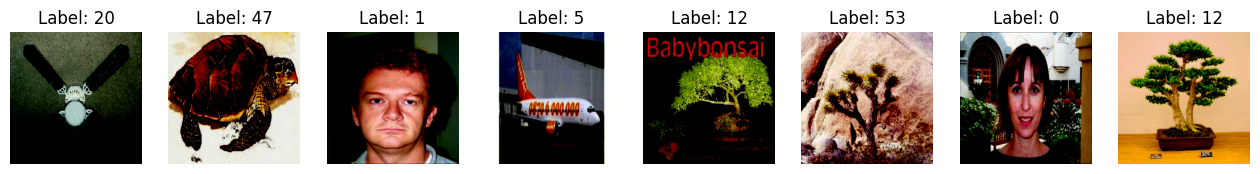

In [20]:
# Visualización de algunas imágenes
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Mostrar las primeras 8 imágenes
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    axes[i].imshow(images[i].permute(1, 2, 0))  # Cambiar dimensiones de canales para matplotlib
    axes[i].set_title(f'Label: {labels[i].item()}')
    axes[i].axis('off')
plt.show()

In [21]:
# Cargar un modelo preentrenado (ResNet18)
model = models.resnet18(pretrained=True)

# Modificar la última capa para adaptarla a las clases de Caltech101 (101 clases)
num_classes = len(train_data.categories) # 101
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Pasar las imágenes por el modelo
with torch.no_grad():  # Desactivar gradientes (no entrenamos ahora)
    outputs = model(images)  # Predicciones sin entrenar
    probabilities = torch.nn.functional.softmax(outputs, dim=1)  # Convertir a probabilidades
    predictions = probabilities.argmax(dim=1)  # Índices de las clases predichas

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


In [22]:
# Mostrar predicciones y etiquetas reales
print("\nResultados:")
for i in range(8):
    true_label = train_data.categories[labels[i].item()]  # Convertir etiqueta a nombre
    predicted_label = train_data.categories[predictions[i].item()]  # Predicción
    print(f"Imagen {i+1}: Real -> {true_label}, Predicho -> {predicted_label}")


Resultados:
Imagen 1: Real -> ceiling_fan, Predicho -> bonsai
Imagen 2: Real -> hawksbill, Predicho -> cannon
Imagen 3: Real -> Faces_easy, Predicho -> cannon
Imagen 4: Real -> airplanes, Predicho -> cannon
Imagen 5: Real -> bonsai, Predicho -> cannon
Imagen 6: Real -> joshua_tree, Predicho -> hawksbill
Imagen 7: Real -> Faces, Predicho -> water_lilly
Imagen 8: Real -> bonsai, Predicho -> wild_cat


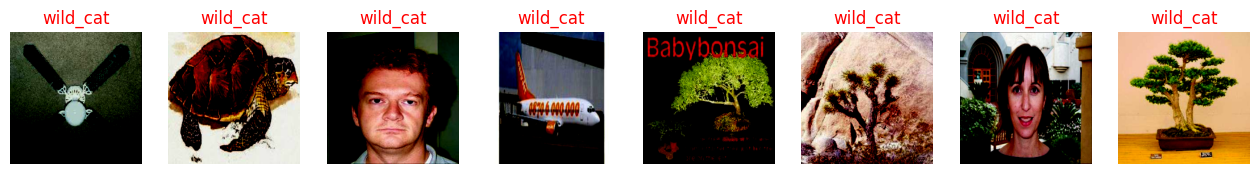

In [24]:
# Mostrar imágenes con predicciones superpuestas
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    axes[i].imshow(images[i].permute(1, 2, 0))  # Cambiar dimensiones de canales para matplotlib
    axes[i].set_title(f'{predicted_label}', color='green' if true_label == predicted_label else 'red')
    axes[i].axis('off')
plt.show()

## 2.1.1 ¡Mejorando el modelo!

¡OJO! Correr esto tomará tiempo

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

# Transformaciones para Caltech101
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convertir a 3 canales
    transforms.Resize((224, 224)),  # Redimensionar a 224x224 para ResNet
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalización para datos entre -1 y 1
])

# Cargar datos
train_data = datasets.Caltech101(root='./data', download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)

# Cargar modelo preentrenado ResNet50
model = models.resnet50(pretrained=True)
num_classes = len(train_data.categories)
model.fc = nn.Linear(model.fc.in_features, num_classes)  # Ajustar última capa
model = model.to("cuda")  # Usar GPU si está disponible

# Configurar pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  # Ajustar solo la última capa

# Entrenar por algunas épocas
model.train()
for epoch in range(3):  # Usar más épocas para mejor rendimiento
    running_loss = 0.0
    for images, labels in train_loader:
        print(f"Entrenando épocs {epoch + 1}")

        images, labels = images.to("cuda"), labels.to("cuda")

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Época {epoch + 1}, Loss: {running_loss / len(train_loader)}")

# Evaluar el modelo en un batch
model.eval()
with torch.no_grad():
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    images, labels = images.to("cuda"), labels.to("cuda")
    outputs = model(images)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    predictions = probabilities.argmax(dim=1)

# Mostrar resultados
print("\nResultados:")
for i in range(8):
    true_label = train_data.categories[labels[i].item()]
    predicted_label = train_data.categories[predictions[i].item()]
    print(f"Imagen {i+1}: Real -> {true_label}, Predicho -> {predicted_label}")


Files already downloaded and verified
Epoch 1, Loss: 1.297113208045416
Epoch 2, Loss: 0.3376486148301731
Epoch 3, Loss: 0.22279570078449873

Resultados:
Imagen 1: Real -> crab, Predicho -> crab
Imagen 2: Real -> ewer, Predicho -> ewer
Imagen 3: Real -> crayfish, Predicho -> crayfish
Imagen 4: Real -> Faces, Predicho -> Faces
Imagen 5: Real -> Motorbikes, Predicho -> Motorbikes
Imagen 6: Real -> crayfish, Predicho -> crayfish
Imagen 7: Real -> hawksbill, Predicho -> hawksbill
Imagen 8: Real -> Motorbikes, Predicho -> Motorbikes


## 3.1. Huggingface

**Dataset:** Datos de IMDb, que contienen reseñas a películas. Esto nos ayudará a clasificarlas.

**Modelo**: Trabajaremos con un modelo preentrenado como BERT o DistilBERT de Hugging Face para procesar texto. Incluiremos la carga de un dataset, preprocesamiento y predicción.

In [25]:
# Instalar huggingface (si no lo tienes ya instalado)
!pip install transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 18.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [26]:
from transformers import pipeline
from datasets import load_dataset
# Cargar un dataset de texto (ejemplo: IMDb para clasificación de reseñas)
dataset = load_dataset("imdb", split="test[:100]")  # Usar solo 100 ejemplos para pruebas

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [28]:
# Mostrar algunas reseñas
print("\nEjemplo de texto:")
print(dataset[33]["text"])
print("\nEtiqueta:", dataset[33]["label"])  # Etiqueta: 0 = Negativo, 1 = Positivo


Ejemplo de texto:
The most positive points in this film were the credits (text style) and some moments in Ice-T's acting. The story-line; two rival gangs having to fight it out, with the sub-plots of betrayal, power and change are well worn plots but in this case painful(very) to wade through. The decrepit scenery, which added slight believability in places, and questionable lighting, constantly distracted from any interest/identification with the characters (the shine off of the actress's forehead/nose was blinding, not to mention other scenes with the same problem.) Not even half way into the film I wanted to know more about how and why it came about as opposed to what was going on on screen. A disappointment if you have seen Ice-T in other roles. Kudos to other actors/actresses who seemed to get into their roles despite the weak direction; Corrupt's side kick and the other restaurant worker.

Etiqueta: 0


In [29]:
# Cargar un pipeline preentrenado para análisis de sentimientos
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [31]:
# Pasar un ejemplo por el modelo
result = classifier(dataset[33]["text"])
print("\nResultado del modelo para una reseña:")
print(f"Texto: {dataset[33]['text'][:300]}...")  # Mostrar los primeros 300 caracteres del texto
print(f"Predicción: {result[0]['label']}, Confianza: {result[0]['score']:.2f}")

# Visualizar resultados en múltiples reseñas
print("\nResultados detallados en las primeras 5 reseñas:")
for i in range(5):
    text = dataset[i]["text"]
    pred = classifier(text)
    label = pred[0]['label']
    confidence = pred[0]['score']

    # Mostrar una porción del texto con la predicción
    print(f"\nReseña {i+1}:")
    print(f"Texto: {text[:300]}...")  # Limitar a los primeros 300 caracteres para legibilidad
    print(f"Predicción: {label} (Confianza: {confidence:.2f})")



Resultado del modelo para una reseña:
Texto: The most positive points in this film were the credits (text style) and some moments in Ice-T's acting. The story-line; two rival gangs having to fight it out, with the sub-plots of betrayal, power and change are well worn plots but in this case painful(very) to wade through. The decrepit scenery, w...
Predicción: NEGATIVE, Confianza: 1.00

Resultados detallados en las primeras 5 reseñas:

Reseña 1:
Texto: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, C...
Predicción: NEGATIVE (Confianza: 1.00)

Reseña 2:
Texto: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles w

## 3.1.1: Probemos nuestras propias reseñas

In [32]:
while True:
    user_input = input("\nEscribe una reseña para clasificar (o escribe 'salir' para terminar):\n")
    if user_input.lower() == "salir":
        print("¡Gracias por probar el modelo!")
        break

    # Pasar la reseña escrita por el modelo
    result = classifier(user_input)
    label = result[0]['label']
    confidence = result[0]['score']

    # Mostrar el resultado de clasificación
    print(f"\nResultado del modelo:")
    print(f"Predicción: {label} (Confianza: {confidence:.2f})")



Escribe una reseña para clasificar (o escribe 'salir' para terminar):
Badlysim, very $hity rotten tomato. I loved the soda in the cafeteria and I ate a lot of popcorns. Recommend the popcorn very much!!

Resultado del modelo:
Predicción: POSITIVE (Confianza: 1.00)

Escribe una reseña para clasificar (o escribe 'salir' para terminar):
Very bad movie, loved the seats and very good view.

Resultado del modelo:
Predicción: POSITIVE (Confianza: 1.00)


KeyboardInterrupt: Interrupted by user